# Public Wolffia SRR29417746 QC, UMAP, and Transfer-Label Review

## tl;dr

This notebook reviews the first public Wolffia run processed through the project workflow: `SRR29417746` from `PRJNA1124135`.

Executed results:

- 2,718 filtered cells and 15,080 Waus8730 genes were loaded from the STARsolo-derived AnnData object.
- The Waus8730 bridge mapped 309 of 340 Arabidopsis model features, giving 90.9% real model-feature coverage.
- Native Waus8730 UMAP/clustering used 2,000 highly variable genes and produced 9 Leiden clusters at resolution 0.6.
- The current transfer model assigned non-ambiguous provisional labels to 368 of 2,718 cells, or 13.5%.
- Final provisional labels were: 2,350 ambiguous cells, 347 photosynthetic/assimilation-like cells, and 21 vascular/transport-like cells.

The main interpretation is that the model remains intentionally conservative on real public Wolffia data. The useful next biological check is whether the non-ambiguous cells occupy coherent native Wolffia clusters and whether their marker genes support the provisional labels.

## Context & Methods

This is a diagnostic analysis notebook for the first public Wolffia model application. It is designed to answer four practical questions:

1. Does the filtered STARsolo matrix have reasonable cell-level QC?
2. Do model-supported cells occupy coherent regions in a native Wolffia UMAP?
3. Are most ambiguous calls concentrated in low-quality cells, or do they represent real unexplained expression states?
4. What should we inspect next before making biological claims?

### Key assumptions

- The input count matrix was generated from `SRR29417746` using STARsolo and the Waus8730.v1 reference.
- The normalized expression object uses library-size normalization to 10,000 counts per cell followed by `log1p`.
- Transfer labels are provisional. They should be reviewed against native Wolffia clusters and marker genes before being described as biological cell types.
- The current Waus8730-to-Arabidopsis bridge maps 309 of 340 model features. Missing model features were zero-filled in the model-input object.

## Setup

In [1]:
from pathlib import Path
import json

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns

sc.settings.verbosity = 2
sc.settings.set_figure_params(dpi=110, frameon=False, figsize=(6, 5))
sns.set_theme(style="whitegrid", context="notebook")

PROJECT_ROOT = Path.cwd()
EXTERNAL_ROOT = Path("/Volumes/LaCie/wolffia_single_cell")

NORMALIZED_H5AD = EXTERNAL_ROOT / "results/processed_h5ad/SRR29417746_normalized_log1p.h5ad"
RAW_H5AD = EXTERNAL_ROOT / "results/processed_h5ad/SRR29417746_raw_counts.h5ad"
MODEL_SUMMARY_JSON = EXTERNAL_ROOT / "results/model_application/SRR29417746/combined_application_summary.json"
MODEL_PREDICTIONS_CSV = EXTERNAL_ROOT / "results/model_application/SRR29417746/combined_leaf_root_predictions.csv"
MODEL_FEATURE_AUDIT_CSV = EXTERNAL_ROOT / "results/waus8730_bridge/SRR29417746_model_feature_mapping_audit.csv"

for path in [NORMALIZED_H5AD, RAW_H5AD, MODEL_SUMMARY_JSON, MODEL_PREDICTIONS_CSV, MODEL_FEATURE_AUDIT_CSV]:
    print(path, "exists=", path.exists())

/var/folders/w0/v9yy8dh97l5cbw6kwc8v949m0000gn/T/ipykernel_45460/740410285.py:12: FutureWarning: The method set_figure_params is deprecated and will be removed in the future. Use :func:`scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi=110, frameon=False, figsize=(6, 5))


/Volumes/LaCie/wolffia_single_cell/results/processed_h5ad/SRR29417746_normalized_log1p.h5ad exists= True
/Volumes/LaCie/wolffia_single_cell/results/processed_h5ad/SRR29417746_raw_counts.h5ad exists= True
/Volumes/LaCie/wolffia_single_cell/results/model_application/SRR29417746/combined_application_summary.json exists= True
/Volumes/LaCie/wolffia_single_cell/results/model_application/SRR29417746/combined_leaf_root_predictions.csv exists= True
/Volumes/LaCie/wolffia_single_cell/results/waus8730_bridge/SRR29417746_model_feature_mapping_audit.csv exists= True


## Data

In [2]:
adata = ad.read_h5ad(NORMALIZED_H5AD)
raw_adata = ad.read_h5ad(RAW_H5AD)
predictions = pd.read_csv(MODEL_PREDICTIONS_CSV)
feature_audit = pd.read_csv(MODEL_FEATURE_AUDIT_CSV)
model_summary = json.loads(MODEL_SUMMARY_JSON.read_text())

adata.obs["total_counts"] = raw_adata.obs["total_counts"].astype(float).reindex(adata.obs_names)
adata.obs["n_genes_by_counts"] = raw_adata.obs["n_genes_by_counts"].astype(float).reindex(adata.obs_names)

predictions = predictions.set_index("cell_id")
for column in [
    "final_label",
    "final_interpretation_status",
    "leaf_label",
    "root_label",
    "leaf_accepted",
    "root_accepted",
    "leaf_minimum_confidence",
    "root_minimum_confidence",
]:
    adata.obs[column] = predictions[column].reindex(adata.obs_names)

adata.obs["final_label"] = adata.obs["final_label"].fillna("missing_prediction")
adata.obs["final_interpretation_status"] = adata.obs["final_interpretation_status"].fillna("missing_prediction")

print(adata)
print("Predictions:", predictions.shape)
print("Mapped model features:", int(feature_audit["present"].sum()), "/", len(feature_audit))

AnnData object with n_obs × n_vars = 2718 × 15080
    obs: 'sample_id', 'project', 'reference', 'total_counts', 'n_genes_by_counts', 'final_label', 'final_interpretation_status', 'leaf_label', 'root_label', 'leaf_accepted', 'root_accepted', 'leaf_minimum_confidence', 'root_minimum_confidence'
    var: 'gene_id', 'feature_type', 'total_counts', 'n_cells_by_counts'
    uns: 'normalization'
    layers: 'counts'
Predictions: (2718, 20)
Mapped model features: 309 / 340


In [3]:
qc_summary = pd.DataFrame({
    "metric": [
        "cells",
        "genes",
        "median_raw_umis_per_cell",
        "median_genes_per_cell",
        "mapped_model_features",
        "model_features",
        "real_model_feature_coverage",
        "leaf_acceptance_rate",
        "root_acceptance_rate",
    ],
    "value": [
        adata.n_obs,
        adata.n_vars,
        adata.obs["total_counts"].median(),
        adata.obs["n_genes_by_counts"].median(),
        int(feature_audit["present"].sum()),
        len(feature_audit),
        feature_audit["present"].mean(),
        model_summary["leaf_acceptance_rate"],
        model_summary["root_acceptance_rate"],
    ],
})
qc_summary

,metric,value
0,cells,2718.000000
1,genes,15080.000000
2,median_raw_umis_per_cell,2595.500000
3,median_genes_per_cell,902.500000
4,mapped_model_features,309.000000
5,model_features,340.000000
6,real_model_feature_coverage,0.908824
7,leaf_acceptance_rate,0.135394
8,root_acceptance_rate,0.000368


## Results

### 1. QC distributions

These plots show whether the filtered STARsolo cells have reasonable count depth and gene detection. The vertical shape matters more than exact thresholds here because this is a first public-data diagnostic.

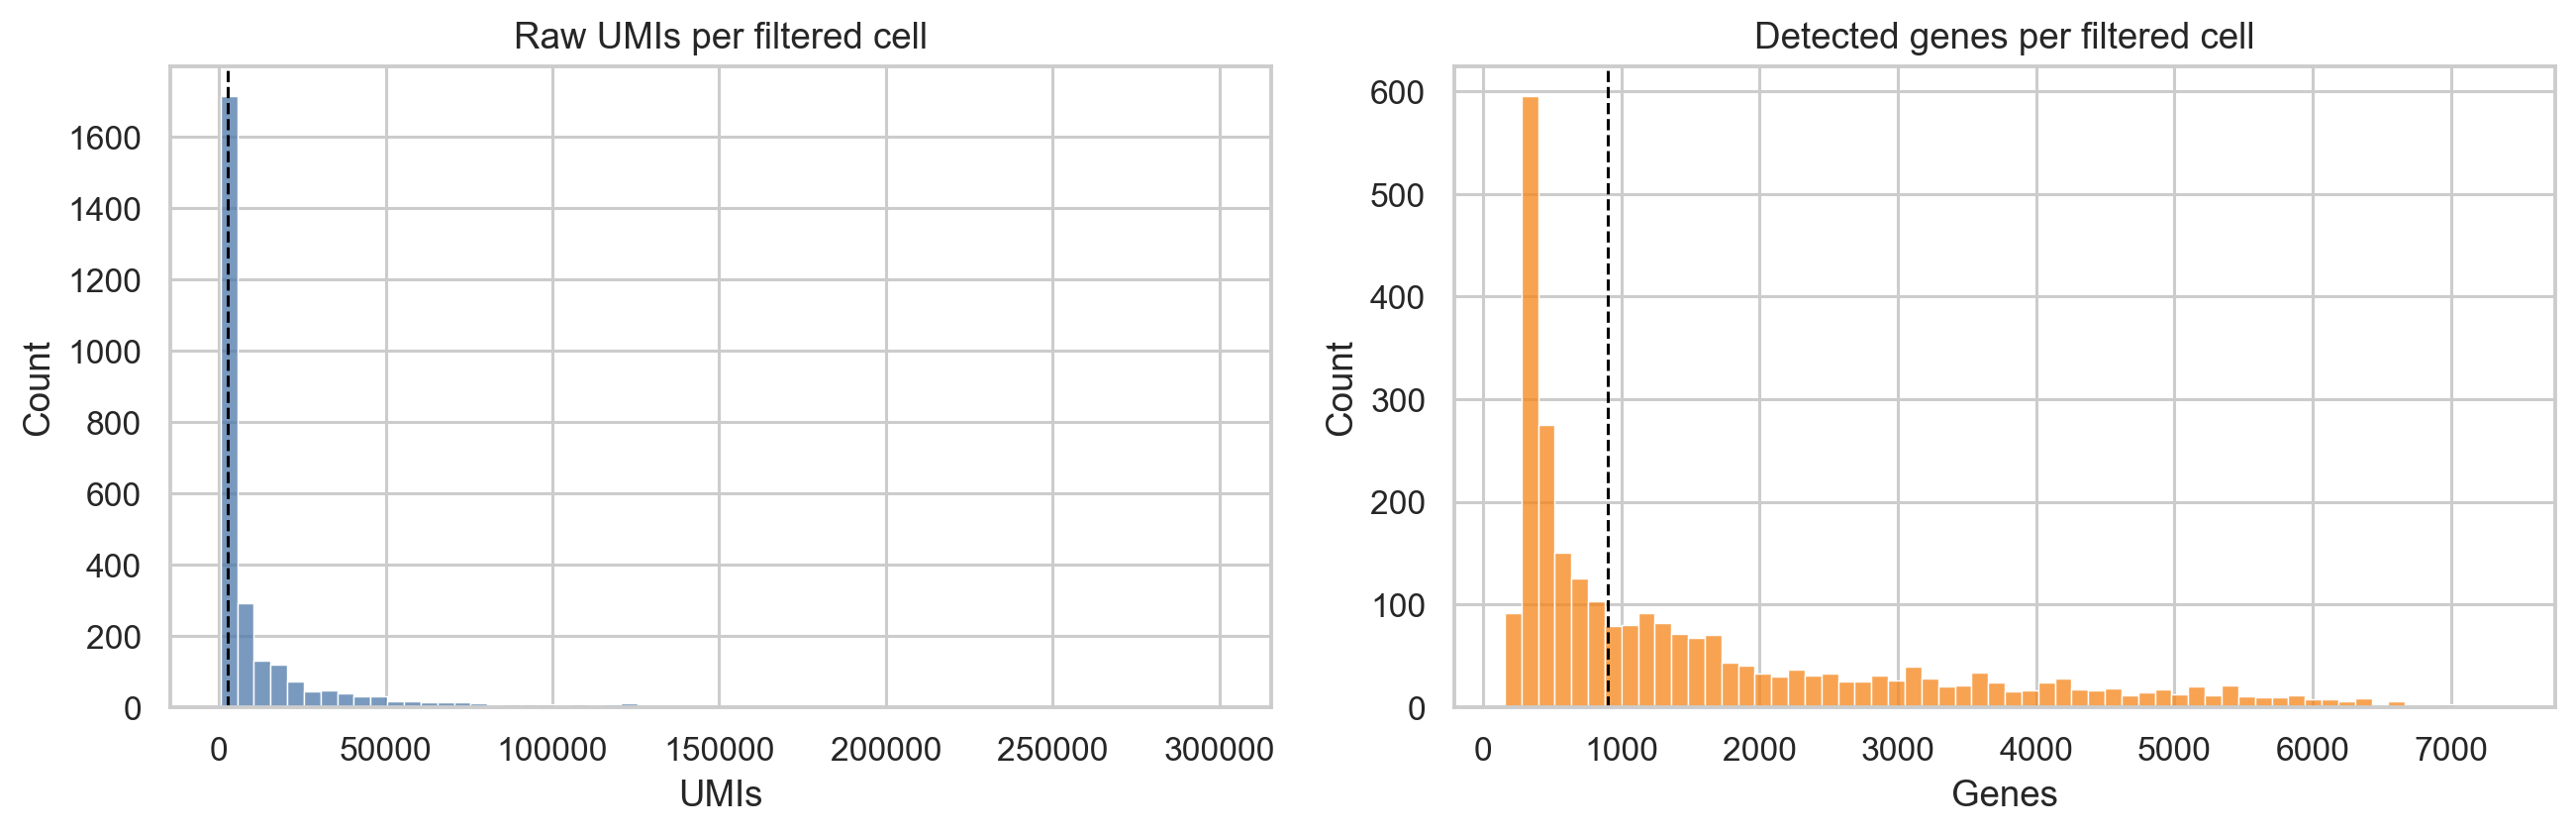

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(adata.obs["total_counts"], bins=60, ax=axes[0], color="#4C78A8")
axes[0].axvline(adata.obs["total_counts"].median(), color="black", linestyle="--", linewidth=1)
axes[0].set_title("Raw UMIs per filtered cell")
axes[0].set_xlabel("UMIs")

sns.histplot(adata.obs["n_genes_by_counts"], bins=60, ax=axes[1], color="#F58518")
axes[1].axvline(adata.obs["n_genes_by_counts"].median(), color="black", linestyle="--", linewidth=1)
axes[1].set_title("Detected genes per filtered cell")
axes[1].set_xlabel("Genes")

plt.tight_layout()

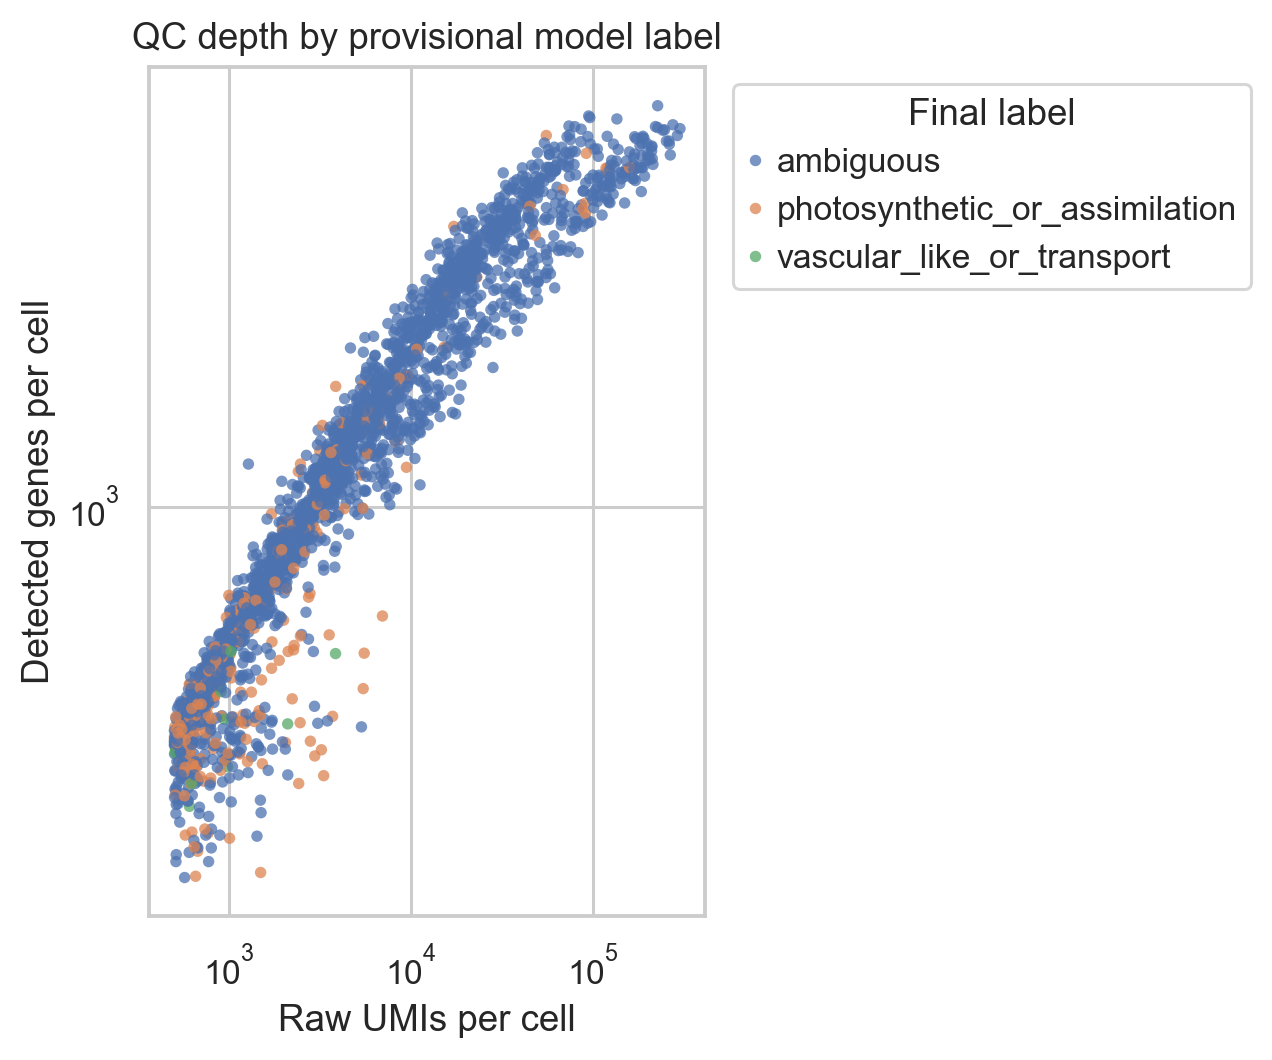

In [5]:
plt.figure(figsize=(6, 5))
sns.scatterplot(
    data=adata.obs,
    x="total_counts",
    y="n_genes_by_counts",
    hue="final_label",
    s=14,
    linewidth=0,
    alpha=0.75,
)
plt.xscale("log")
plt.yscale("log")
plt.title("QC depth by provisional model label")
plt.xlabel("Raw UMIs per cell")
plt.ylabel("Detected genes per cell")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Final label")
plt.tight_layout()

### 2. Build native Wolffia UMAP

The UMAP is computed from Waus8730 expression, not from the 340-feature model-input object. This helps us ask whether transfer labels align with native Wolffia expression structure.

In [6]:
adata_umap = adata.copy()

# Keep the analysis lightweight and deterministic for a small public run.
sc.pp.highly_variable_genes(adata_umap, n_top_genes=2000, flavor="seurat")
sc.pp.scale(adata_umap, max_value=10)
sc.tl.pca(adata_umap, n_comps=40, svd_solver="arpack", random_state=42)
sc.pp.neighbors(adata_umap, n_neighbors=15, n_pcs=30, random_state=42)
sc.tl.umap(adata_umap, random_state=42)
sc.tl.leiden(adata_umap, resolution=0.6, key_added="leiden_0_6")

adata.obs[["UMAP1", "UMAP2", "leiden_0_6"]] = pd.DataFrame(
    {
        "UMAP1": adata_umap.obsm["X_umap"][:, 0],
        "UMAP2": adata_umap.obsm["X_umap"][:, 1],
        "leiden_0_6": adata_umap.obs["leiden_0_6"].astype(str).values,
    },
    index=adata.obs_names,
)

print("HVGs:", int(adata_umap.var["highly_variable"].sum()))
print("Leiden clusters:", adata.obs["leiden_0_6"].nunique())

extracting highly variable genes


    finished (0:00:01)


computing PCA


    with n_comps=40


/opt/anaconda3/lib/python3.12/functools.py:907: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


...

    finished (0:00:02)


running Leiden clustering


/var/folders/w0/v9yy8dh97l5cbw6kwc8v949m0000gn/T/ipykernel_45460/1717975424.py:9: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata_umap, resolution=0.6, key_added="leiden_0_6")


    finished (0:00:00)


HVGs: 2000
Leiden clusters: 9


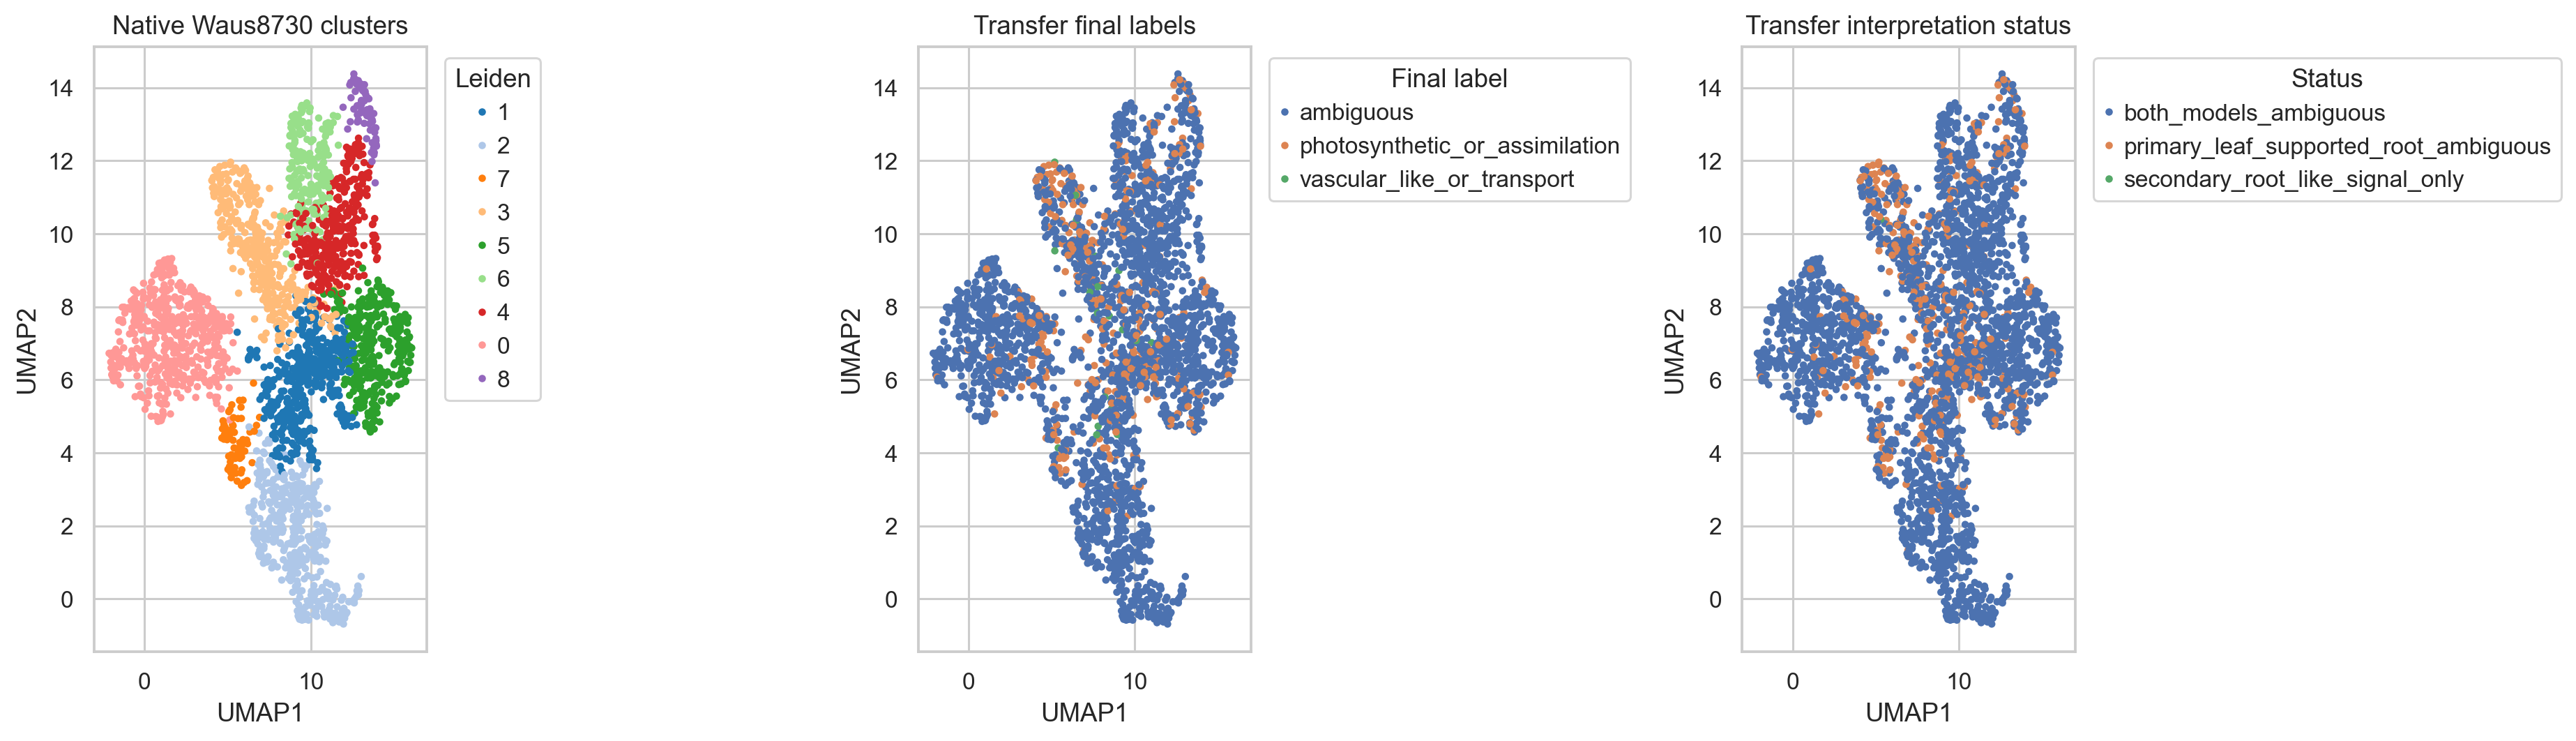

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

sns.scatterplot(data=adata.obs, x="UMAP1", y="UMAP2", hue="leiden_0_6", s=12, linewidth=0, ax=axes[0], palette="tab20")
axes[0].set_title("Native Waus8730 clusters")
axes[0].legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Leiden")

sns.scatterplot(data=adata.obs, x="UMAP1", y="UMAP2", hue="final_label", s=12, linewidth=0, ax=axes[1])
axes[1].set_title("Transfer final labels")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Final label")

sns.scatterplot(data=adata.obs, x="UMAP1", y="UMAP2", hue="final_interpretation_status", s=12, linewidth=0, ax=axes[2])
axes[2].set_title("Transfer interpretation status")
axes[2].legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Status")

for ax in axes:
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")
plt.tight_layout()

### 3. Cluster-level relationship between native Wolffia structure and transfer labels

This table asks whether accepted transfer labels are spread randomly or enriched in specific native Wolffia clusters.

In [8]:
cluster_label_counts = pd.crosstab(adata.obs["leiden_0_6"], adata.obs["final_label"])
cluster_label_fraction = cluster_label_counts.div(cluster_label_counts.sum(axis=1), axis=0).fillna(0)
cluster_summary = cluster_label_counts.join(
    cluster_label_fraction.add_prefix("fraction_")
).sort_index()
cluster_summary

final_label,ambiguous,photosynthetic_or_assimilation,vascular_like_or_transport,fraction_ambiguous,fraction_photosynthetic_or_assimilation,fraction_vascular_like_or_transport
leiden_0_6,,,,,,
0,450,47,0,0.905433,0.094567,0.000000
1,369,91,10,0.785106,0.193617,0.021277
2,397,12,0,0.970660,0.029340,0.000000
3,250,93,10,0.708215,0.263456,0.028329
4,307,22,0,0.933131,0.066869,0.000000
5,304,20,0,0.938272,0.061728,0.000000
6,165,28,0,0.854922,0.145078,0.000000
7,53,20,1,0.716216,0.270270,0.013514
8,55,14,0,0.797101,0.202899,0.000000


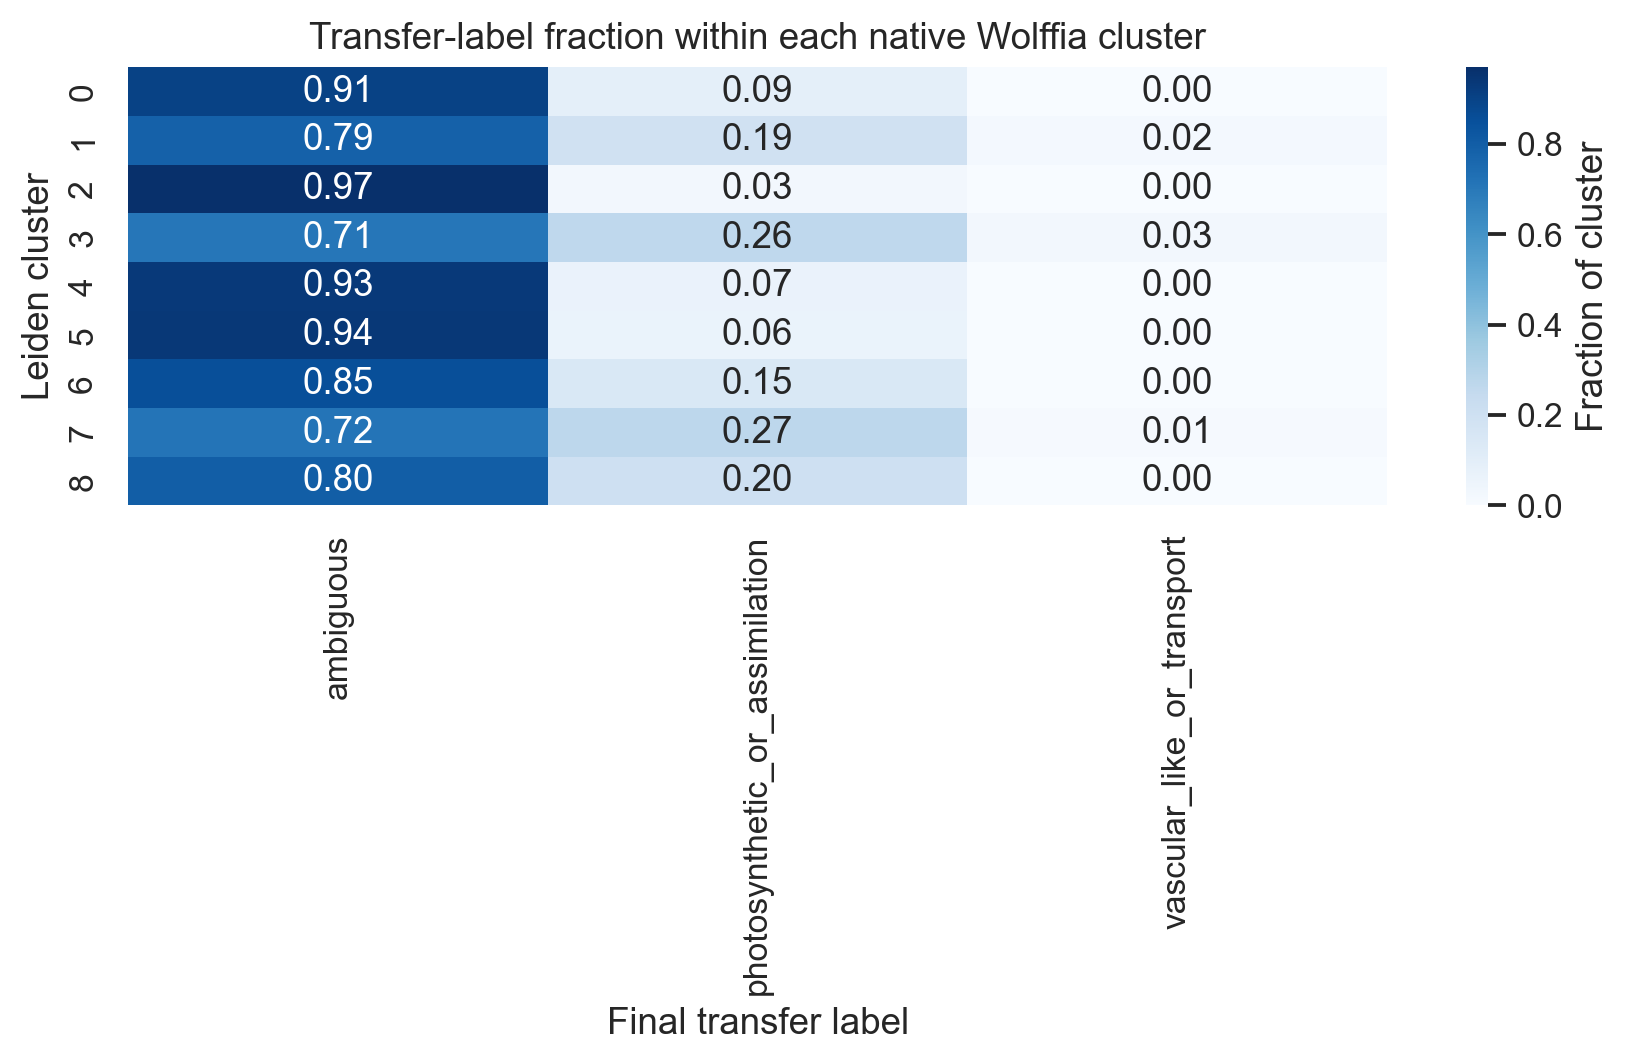

In [9]:
plt.figure(figsize=(8, 5))
sns.heatmap(cluster_label_fraction, annot=True, fmt=".2f", cmap="Blues", cbar_kws={"label": "Fraction of cluster"})
plt.title("Transfer-label fraction within each native Wolffia cluster")
plt.xlabel("Final transfer label")
plt.ylabel("Leiden cluster")
plt.tight_layout()

### 4. Marker-gene scan for native clusters

This is an initial marker scan. The goal is to identify candidate Waus8730 genes that distinguish native clusters, then later connect those genes to functional annotations and Arabidopsis orthologs.

In [10]:
sc.tl.rank_genes_groups(adata_umap, groupby="leiden_0_6", method="wilcoxon", key_added="rank_genes_leiden_0_6")
marker_table = sc.get.rank_genes_groups_df(adata_umap, group=None, key="rank_genes_leiden_0_6")
marker_table = marker_table.sort_values(["group", "scores"], ascending=[True, False])
marker_table.head(20)

ranking genes


    finished (0:00:02)


/opt/anaconda3/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:485: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/opt/anaconda3/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:485: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/opt/anaconda3/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:485: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/opt/anaconda3/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:485: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/opt/anaconda3/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:485: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/opt/anaconda3/lib/python3.12/site-packages/scanpy/tools/_ra

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,0,Waus8730.v1.chr5.g116730,33.803883,NaN,1.729537e-250,2.608142e-246
1,0,Waus8730.v1.chr16.g057130,32.963375,NaN,2.721184e-238,2.051773e-234
2,0,Waus8730.v1.chr4.g106130,32.070072,NaN,1.152779e-225,5.794634e-222
3,0,Waus8730.v1.chr12.g029600,31.762672,NaN,2.122384e-221,8.001387e-218
4,0,Waus8730.v1.chr8.g140070,31.497038,NaN,9.537017e-218,2.876364e-214
5,0,Waus8730.v1.chr9.g142880,31.255619,NaN,1.872597e-214,4.706462e-211
6,0,Waus8730.v1.chr17.g061240,31.057926,NaN,8.917129e-212,1.921004e-208
7,0,Waus8730.v1.chr1.g001070,30.379831,NaN,1.014566e-202,1.912456e-199
8,0,Waus8730.v1.chr14.g046510,29.303663,NaN,9.314695e-189,1.560729e-185
9,0,Waus8730.v1.chr1.g008030,29.299427,NaN,1.054734e-188,1.590539e-185


In [11]:
top_markers = (
    marker_table
    .query("pvals_adj < 0.05")
    .groupby("group")
    .head(5)
    [["group", "names", "scores", "logfoldchanges", "pvals_adj"]]
)
top_markers

,group,names,scores,logfoldchanges,pvals_adj
0,0,Waus8730.v1.chr5.g116730,33.803883,NaN,2.608142e-246
1,0,Waus8730.v1.chr16.g057130,32.963375,NaN,2.051773e-234
2,0,Waus8730.v1.chr4.g106130,32.070072,NaN,5.794634e-222
3,0,Waus8730.v1.chr12.g029600,31.762672,NaN,8.001387e-218
4,0,Waus8730.v1.chr8.g140070,31.497038,NaN,2.876364e-214
15080,1,Waus8730.v1.chr8.g137570,10.586090,NaN,2.190601e-24
15081,1,Waus8730.v1.chr8.g140090,10.084685,NaN,2.469227e-22
15082,1,Waus8730.v1.chr5.g116260,9.135745,NaN,1.206363e-18
15083,1,Waus8730.v1.chr4.g102000,7.514871,NaN,5.312686e-13
15084,1,Waus8730.v1.chr5.g115190,7.335844,NaN,1.915013e-12


### 5. Annotate cluster markers with Waus8730 functional descriptions

This step connects top native Wolffia cluster markers to Waus8730 functional annotations from the eggNOG-mapper table. This makes the marker list biologically readable instead of leaving it as gene IDs only.

In [12]:
import re

ANNOTATION_CANDIDATES = [
    EXTERNAL_ROOT / "results/waus8730_bridge/waus8730_functional_annotation.csv",
    Path("/Users/bella/Desktop/Research/single-cell RNA seq/Waus 8730 single cell/waemap.csv"),
]

annotation_path = next((candidate for candidate in ANNOTATION_CANDIDATES if candidate.exists()), None)
if annotation_path is None:
    raise FileNotFoundError("Could not find Waus8730 functional annotation table. Expected one of: " + "; ".join(map(str, ANNOTATION_CANDIDATES)))

print("Using annotation table:", annotation_path)

def strip_waus8730_transcript(value):
    value = str(value).strip()
    return re.sub(r"\.t\d+$", "", value)

annotation_raw = pd.read_csv(annotation_path, dtype=str).fillna("")
if "waus8730_gene_id" not in annotation_raw.columns:
    query_column = "#query" if "#query" in annotation_raw.columns else annotation_raw.columns[0]
    annotation_raw = annotation_raw.rename(columns={query_column: "waus8730_transcript_id"})
    annotation_raw["waus8730_gene_id"] = annotation_raw["waus8730_transcript_id"].map(strip_waus8730_transcript)

annotation_columns = [
    "waus8730_gene_id",
    "waus8730_transcript_id",
    "Description",
    "Preferred_name",
    "GOs",
    "KEGG_ko",
    "KEGG_Pathway",
    "PFAMs",
]
annotation_columns = [column for column in annotation_columns if column in annotation_raw.columns]
annotation = (
    annotation_raw[annotation_columns]
    .drop_duplicates("waus8730_gene_id")
    .sort_values("waus8730_gene_id")
)

annotated_top_markers = top_markers.merge(
    annotation,
    left_on="names",
    right_on="waus8730_gene_id",
    how="left",
)

annotated_top_markers[
    [column for column in ["group", "names", "Description", "Preferred_name", "scores", "logfoldchanges", "pvals_adj"] if column in annotated_top_markers.columns]
]

Using annotation table: /Volumes/LaCie/wolffia_single_cell/results/waus8730_bridge/waus8730_functional_annotation.csv


,group,names,Description,Preferred_name,scores,logfoldchanges,pvals_adj
0,0,Waus8730.v1.chr5.g116730,"Protein of unknown function, DUF538",-,33.803883,NaN,2.608142e-246
1,0,Waus8730.v1.chr16.g057130,3-ketoacyl-coa synthase,-,32.963375,NaN,2.051773e-234
2,0,Waus8730.v1.chr4.g106130,Late embryogenesis abundant protein,-,32.070072,NaN,5.794634e-222
3,0,Waus8730.v1.chr12.g029600,NaN,NaN,31.762672,NaN,8.001387e-218
4,0,Waus8730.v1.chr8.g140070,NaN,NaN,31.497038,NaN,2.876364e-214
5,1,Waus8730.v1.chr8.g137570,Photosystem II 10 kDa polypeptide,-,10.586090,NaN,2.190601e-24
6,1,Waus8730.v1.chr8.g140090,NaN,NaN,10.084685,NaN,2.469227e-22
7,1,Waus8730.v1.chr5.g116260,RuBisCO catalyzes two reactions the carboxylat...,-,9.135745,NaN,1.206363e-18
8,1,Waus8730.v1.chr4.g102000,Peroxisomal (S)-2-hydroxy-acid oxidase,-,7.514871,NaN,5.312686e-13
9,1,Waus8730.v1.chr5.g115190,The light-harvesting complex (LHC) functions a...,-,7.335844,NaN,1.915013e-12


In [13]:
marker_function_summary = (
    annotated_top_markers
    .assign(
        marker_with_description=lambda df: df.apply(
            lambda row: f"{row['names']}: {row.get('Description', '')}" if row.get('Description', '') else str(row['names']),
            axis=1,
        )
    )
    .groupby("group")["marker_with_description"]
    .apply(lambda values: " | ".join(values.head(5)))
    .reset_index(name="top_marker_descriptions")
)

marker_function_summary

,group,top_marker_descriptions
0,0,Waus8730.v1.chr5.g116730: Protein of unknown f...
1,1,Waus8730.v1.chr8.g137570: Photosystem II 10 kD...
2,2,Waus8730.v1.chr9.g145240: Plant non-specific l...
3,3,Waus8730.v1.chrC.g149180: Bacterial RNA polyme...
4,4,Waus8730.v1.chr11.g023670: RuBisCO catalyzes t...
5,5,Waus8730.v1.chr11.g026730: Belongs to the tetr...
6,6,Waus8730.v1.chr7.g133850: Involved in biosynth...
7,7,Waus8730.v1.chr12.g029500: nan | Waus8730.v1.c...
8,8,Waus8730.v1.chr7.g126840: Germin-like protein ...


The table above is the first place to look for biological meaning. If a model-supported cluster is enriched for photosynthesis, metabolism, transport, stress, or growth-related descriptions, that supports using the transfer label as a provisional program label. If top markers are mostly unknown proteins or mixed functions, the cluster should remain conservative/ambiguous until additional evidence is available.

## Takeaways

In [14]:
final_counts = adata.obs["final_label"].value_counts()
status_counts = adata.obs["final_interpretation_status"].value_counts()
accepted_cells = int((adata.obs["final_label"] != "ambiguous").sum())

print(f"Cells analyzed: {adata.n_obs:,}")
print(f"Median raw UMIs per cell: {adata.obs['total_counts'].median():,.1f}")
print(f"Median detected genes per cell: {adata.obs['n_genes_by_counts'].median():,.1f}")
print(f"Mapped model features: {int(feature_audit['present'].sum())}/{len(feature_audit)} ({feature_audit['present'].mean():.1%})")
print(f"Accepted non-ambiguous final labels: {accepted_cells}/{adata.n_obs} ({accepted_cells / adata.n_obs:.1%})")
print("\nFinal label counts:")
print(final_counts.to_string())
print("\nStatus counts:")
print(status_counts.to_string())

Cells analyzed: 2,718
Median raw UMIs per cell: 2,595.5
Median detected genes per cell: 902.5
Mapped model features: 309/340 (90.9%)
Accepted non-ambiguous final labels: 368/2718 (13.5%)

Final label counts:
final_label
ambiguous                         2350
photosynthetic_or_assimilation     347
vascular_like_or_transport          21

Status counts:
final_interpretation_status
both_models_ambiguous                    2349
primary_leaf_supported_root_ambiguous     368
secondary_root_like_signal_only             1


### Interpretation checklist

After execution, review the UMAP and cluster-label heatmap before making biological claims. The most useful next checks are:

1. whether photosynthetic/assimilation-like cells occupy coherent native Wolffia clusters,
2. whether vascular/transport-like cells form a small coherent group or look scattered,
3. whether ambiguous cells are mostly low-count cells or genuine native clusters, and
4. whether top Waus8730 cluster markers have functional annotations consistent with the provisional labels.

If these checks look coherent, the next step is to process the remaining public runs from the same project and test whether the same broad patterns reproduce.